In [17]:
import numpy as np
import os
import pickle

In [18]:
with open('./data/replay_buffer.npy', 'rb') as f:
    data = np.load(f, allow_pickle=True).item()

In [19]:
# get keys of the npy file
keys = data.keys()
keys

dict_keys(['states', 'next_states', 'actions', 'rewards', 'dones'])

# Reward Distribution

Mean reward: 0.48796598316200834
Median reward: 0.34305145000000004
Min reward: -1.8403335
Max reward: 1.99298305


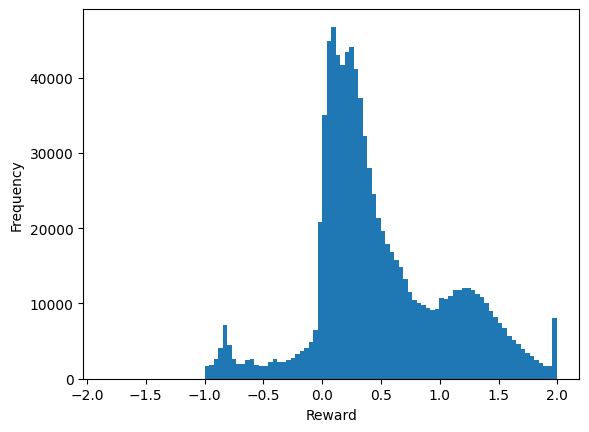

In [20]:
# plot rewards distribution

rewards = data['rewards']
rewards = rewards.flatten()
rewards = rewards[rewards != -999]

import matplotlib.pyplot as plt

print(f'Mean reward: {np.mean(rewards)}')
print(f'Median reward: {np.median(rewards)}')
print(f'Min reward: {np.min(rewards)}')
print(f'Max reward: {np.max(rewards)}')

plt.hist(rewards, bins=100)
plt.xlabel('Reward')
plt.ylabel('Frequency')
plt.show()

# Log Scaled Reward

Mean: 0.3441993473307248, Std: 0.3596676055949006
Min: -1.0439214748562664, Max: 1.0962705656403595


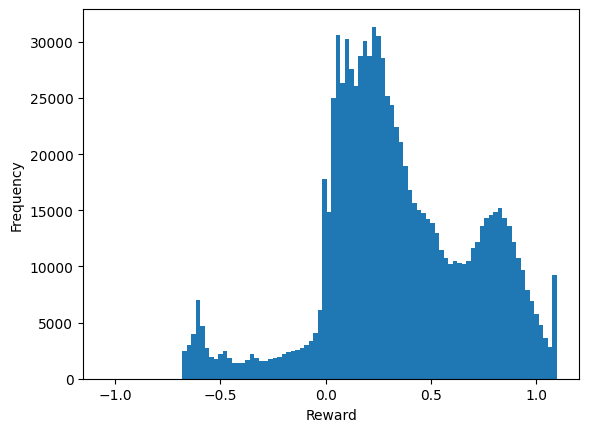

In [21]:
from sklearn.preprocessing import RobustScaler

rewards = data['rewards']
rewards = rewards.flatten()
rewards = rewards[rewards != -999]
rewards = rewards.reshape(-1, 1)

rewards = np.sign(rewards) * np.log1p(np.abs(rewards))

mean = np.mean(rewards)
std = np.std(rewards)

print(f'Mean: {mean}, Std: {std}')
print(f'Min: {np.min(rewards)}, Max: {np.max(rewards)}')

# plot rewards distribution

plt.hist(rewards, bins=100)
plt.xlabel('Reward')
plt.ylabel('Frequency')
plt.show()

# Log scaled + Tanh

Mean: 0.08520134160019216, Std: 0.08864740003708911
Min: -0.2552122757626908, Max: 0.2674057085195365


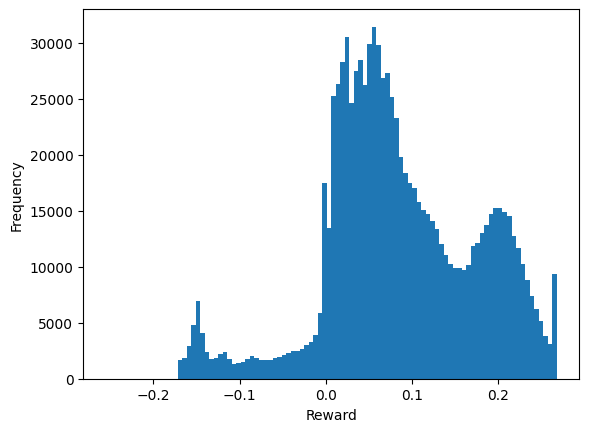

In [22]:
import numpy as np

rewards = data['rewards']
rewards = rewards.flatten()
rewards = rewards[rewards != -999]
rewards = rewards.reshape(-1, 1)

rewards = np.sign(rewards) * np.log1p(np.abs(rewards))

c = 4.0
# apply tanh
rewards = np.tanh(rewards / c)

mean = np.mean(rewards)
std = np.std(rewards)

print(f'Mean: {mean}, Std: {std}')
print(f'Min: {np.min(rewards)}, Max: {np.max(rewards)}')

# plot rewards distribution

plt.hist(rewards, bins=100)
plt.xlabel('Reward')
plt.ylabel('Frequency')
plt.show()

# Robust Scaling + Log

Mean: 0.11429128490772306, Std: 0.5123819861213271
Min: -1.404302160383848, Max: 1.2005529523410343


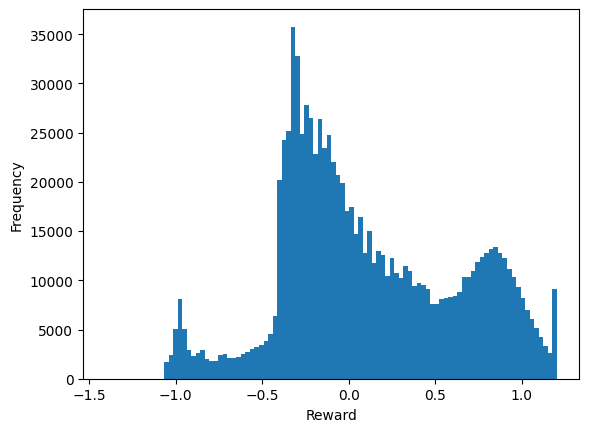

In [23]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
rewards = data['rewards']
rewards = rewards.flatten()
rewards = rewards[rewards != -999]
rewards = rewards.reshape(-1, 1)
scaler.fit(rewards)
rewards = scaler.transform(rewards)

# apply log scaling to rewards: sign(x) * log(1 + abs(x))

rewards = np.sign(rewards) * np.log1p(np.abs(rewards))

mean = np.mean(rewards)
std = np.std(rewards)

print(f'Mean: {mean}, Std: {std}')
print(f'Min: {np.min(rewards)}, Max: {np.max(rewards)}')

# plot rewards distribution

plt.hist(rewards, bins=100)
plt.xlabel('Reward')
plt.ylabel('Frequency')
plt.show()

# Robust Scaling + Log + Clipping

Mean: 0.11014759199599997, Std: 0.5038928643340265
Min: -1.0, Max: 1.0


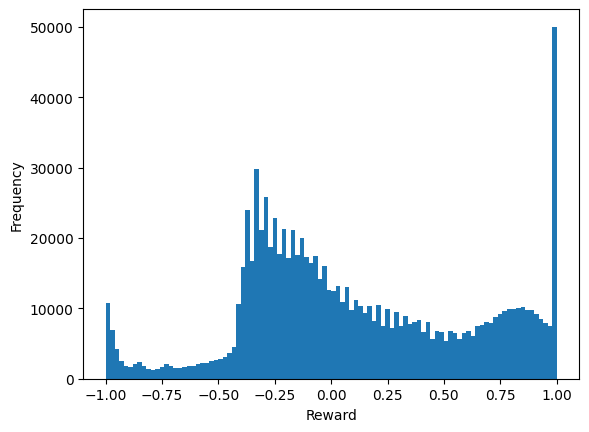

In [24]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
rewards = data['rewards']
rewards = rewards.flatten()
rewards = rewards[rewards != -999]
rewards = rewards.reshape(-1, 1)
scaler.fit(rewards)
rewards = scaler.transform(rewards)

# apply log scaling to rewards: sign(x) * log(1 + abs(x))

rewards = np.sign(rewards) * np.log1p(np.abs(rewards))

# clip to [-1, 1]
rewards = np.clip(rewards, -1, 1)

mean = np.mean(rewards)
std = np.std(rewards)

print(f'Mean: {mean}, Std: {std}')
print(f'Min: {np.min(rewards)}, Max: {np.max(rewards)}')

# plot rewards distribution

plt.hist(rewards, bins=100)
plt.xlabel('Reward')
plt.ylabel('Frequency')
plt.show()

# Log + Min/Max Scaling

Mean: 0.2971927714158603, Std: 0.33610778732869284
Min: -1.0, Max: 1.0


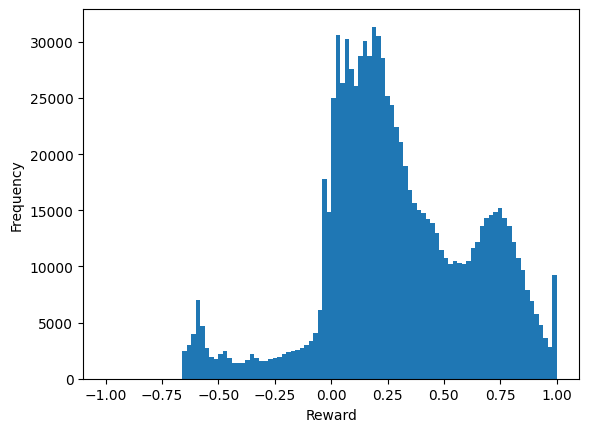

In [26]:
from sklearn.preprocessing import RobustScaler

rewards = data['rewards']
rewards = rewards.flatten()
rewards = rewards[rewards != -999]
rewards = rewards.reshape(-1, 1)

rewards = np.sign(rewards) * np.log1p(np.abs(rewards))

# max-min scaling
rewards = (rewards - np.min(rewards)) / (np.max(rewards) - np.min(rewards))
rewards = rewards * 2 - 1

mean = np.mean(rewards)
std = np.std(rewards)

print(f'Mean: {mean}, Std: {std}')
print(f'Min: {np.min(rewards)}, Max: {np.max(rewards)}')

# plot rewards distribution

plt.hist(rewards, bins=100)
plt.xlabel('Reward')
plt.ylabel('Frequency')
plt.show()

# Min Max Scaling

Mean: 0.21477026631782253, Std: 0.29573860434122673
Min: -1.0, Max: 1.0


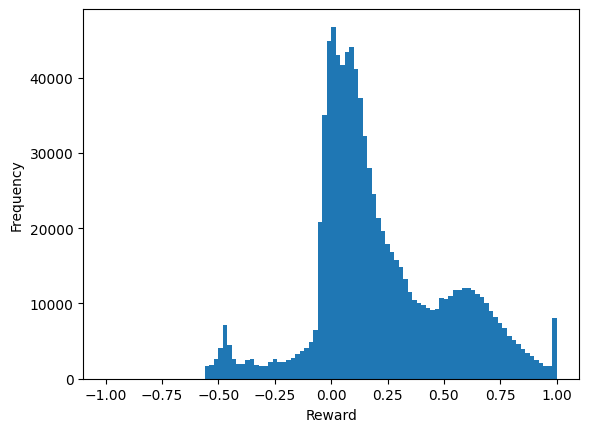

In [27]:
# normalize rewards to be in range [-1, 1]

rewards = data['rewards']
rewards = rewards.flatten()
rewards = rewards[rewards != -999]

rewards = (rewards - np.min(rewards)) / (np.max(rewards) - np.min(rewards))
rewards = 2 * rewards - 1

mean = np.mean(rewards)
std = np.std(rewards)

print(f'Mean: {mean}, Std: {std}')
print(f'Min: {np.min(rewards)}, Max: {np.max(rewards)}')

# plot rewards distribution

plt.hist(rewards, bins=100)
plt.xlabel('Reward')
plt.ylabel('Frequency')
plt.show()

# Min Max without Outliers

Mean: 0.21477026631782253, Std: 0.29573860434122673
Min: -1.0, Max: 1.0


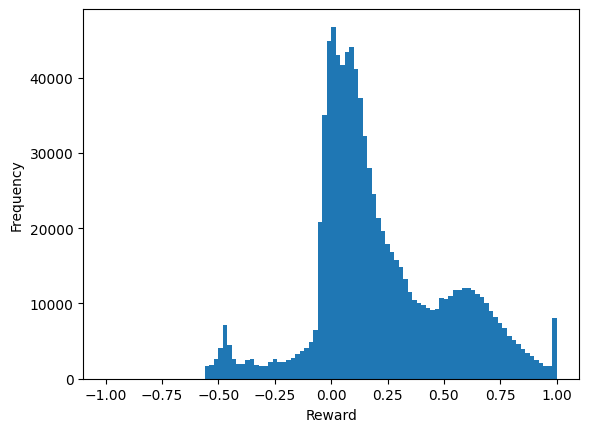

In [28]:
rewards = data['rewards']
rewards = rewards.flatten()
rewards = rewards[rewards != -999]

# normalize rewards to be in range [-1, 1]

# drop negative outliers
rewards = np.clip(rewards, -100, None)

rewards = (rewards - np.min(rewards)) / (np.max(rewards) - np.min(rewards))
rewards = 2 * rewards - 1

mean = np.mean(rewards)
std = np.std(rewards)

print(f'Mean: {mean}, Std: {std}')
print(f'Min: {np.min(rewards)}, Max: {np.max(rewards)}')

# plot rewards distribution

plt.hist(rewards, bins=100)
plt.xlabel('Reward')
plt.ylabel('Frequency')
plt.show()


# Robust Scaling

Mean: 0.20393862268827953, Std: 0.797701203655586
Min: -3.07268366937026, Max: 2.3219532968283687


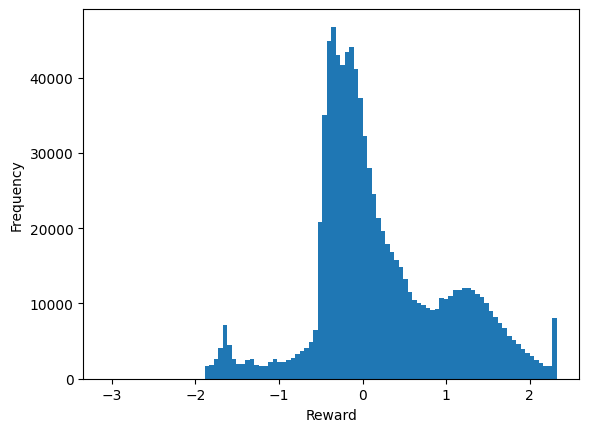

In [29]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
rewards = data['rewards']
rewards = rewards.flatten()
rewards = rewards[rewards != -999]
rewards = rewards.reshape(-1, 1)
scaler.fit(rewards)
rewards = scaler.transform(rewards)

mean = np.mean(rewards)
std = np.std(rewards)

print(f'Mean: {mean}, Std: {std}')
print(f'Min: {np.min(rewards)}, Max: {np.max(rewards)}')

# plot rewards distribution

plt.hist(rewards, bins=100)
plt.xlabel('Reward')
plt.ylabel('Frequency')
plt.show()

# Z-Score Scaling

Mean: 1.4957607877790447e-16, Std: 1.0000000000000002
Min: -4.107580980250406, Max: 2.6551478980274426


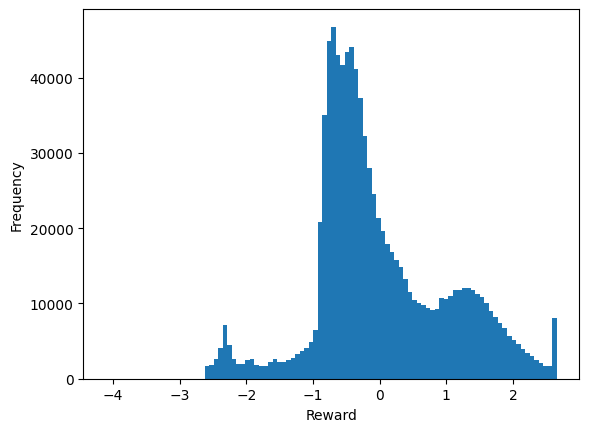

In [30]:
rewards = data['rewards']
rewards = rewards.flatten()
rewards = rewards[rewards != -999]

# z-score normalization to center rewards at 0 with std 1

mean = np.mean(rewards)
std = np.std(rewards)

rewards = (rewards - mean) / std

mean = np.mean(rewards)
std = np.std(rewards)

print(f'Mean: {mean}, Std: {std}')
print(f'Min: {np.min(rewards)}, Max: {np.max(rewards)}')

# plot rewards distribution

plt.hist(rewards, bins=100)
plt.xlabel('Reward')
plt.ylabel('Frequency')
plt.show()

# Check Feature Distribution

In [31]:
# import matplotlib.pyplot as plt

In [32]:
# features = list(data[0].keys())

# features.remove('Previous actions')

# all_features = {}
# for feat in features:
#     all_features[feat] = []

# for call in data:
#     for feat in features:
#         feat_vec = np.array(call[feat])
#         all_features[feat].append(feat_vec)

# for feat in features:
#     all_features[feat] = np.concatenate(all_features[feat], axis=0)

In [33]:
# # plot distribution of each feature

# for feat in features:
#     feat_vec = process_state_feature(feat, all_features[feat])
#     plt.hist(feat_vec, bins=100)
#     plt.title(f'{feat}, min: {np.min(feat_vec)}, max: {np.max(feat_vec)}')
#     plt.show()